In [28]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

In [17]:
%run useful.py

# training/validation fractions
perc_train = np.arange(0.1, 1, 0.1)
perc_valid = 1 - perc_train

print(perc_valid)

[0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]


(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: [ 1200  2400  3600  4800  6000  7200  8400  9600 10800]
valid: [10800  9600  8400  7200  6000  4800  3599  2399  1199]


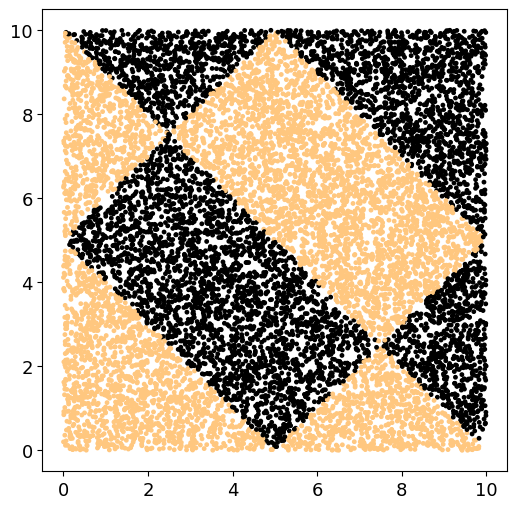

In [22]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = (perc_train * N).astype(int)
N_valid = (perc_valid * N).astype(int)
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}')

plot_data(x,y)

In [23]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

def sets_constructor(N_train, N_valid):

    # split data into train/validation sets and check
    (x_train, y_train) = (x[0:N_train],y[0:N_train])
    (x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
    print("Train:",len(x_train),"\t Validation:",len(x_valid))


    x_train_mean = np.mean(x_train, axis=0)
    x_train_std = np.std(x_train, axis=0)
    #print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

    x_valid_mean = np.mean(x_valid, axis=0)
    x_valid_std = np.std(x_valid, axis=0)
    #print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)


    x_train = Standardize(x_train, x_train_mean, x_train_std)
    x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
    print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

    return x_train, y_train, x_valid, y_valid

In [35]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)


n_sets = N_train.size

output_file = "results_2a.csv"
results_list = []

for i in range(n_sets):
    
    x_train, y_train, x_valid, y_valid = sets_constructor(N_train[i], N_valid[i])

    model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'],
                )
    nepoch=200
    
    fit = model.fit(x_train, y_train,
                epochs = nepoch, batch_size = 50,
                validation_data=(x_valid,y_valid),
                verbose=2)
    
    res = {
        '% training data' : perc_train[i],
        '% validation data' : perc_valid[i],
        'val_loss': fit.history['val_loss'][-1], # Ultimo valore di validation
        'val_accuracy': fit.history['val_accuracy'][-1]
    }
    results_list.append(res)
    pd.DataFrame([res]).to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))
    print(f"Completed run {i} of {n_sets}")

Train: 1200 	 Validation: 10800
after rescaling (train):
mean value= [-4.95437025e-16 -1.07247544e-15 -3.38895578e-16 -2.44859688e-15
 -7.64666108e-16 -6.57807142e-16 -2.75335310e-16 -2.45729363e-16] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]
Epoch 1/200


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 - 1s - 56ms/step - accuracy: 0.5208 - loss: 0.6911 - val_accuracy: 0.5106 - val_loss: 0.6908
Epoch 2/200
24/24 - 1s - 25ms/step - accuracy: 0.5008 - loss: 0.6904 - val_accuracy: 0.5296 - val_loss: 0.6878
Epoch 3/200
24/24 - 1s - 23ms/step - accuracy: 0.5408 - loss: 0.6850 - val_accuracy: 0.5330 - val_loss: 0.6855
Epoch 4/200
24/24 - 1s - 24ms/step - accuracy: 0.5433 - loss: 0.6838 - val_accuracy: 0.5387 - val_loss: 0.6837
Epoch 5/200
24/24 - 1s - 22ms/step - accuracy: 0.5492 - loss: 0.6820 - val_accuracy: 0.5413 - val_loss: 0.6816
Epoch 6/200
24/24 - 1s - 24ms/step - accuracy: 0.5592 - loss: 0.6799 - val_accuracy: 0.5393 - val_loss: 0.6802
Epoch 7/200
24/24 - 1s - 22ms/step - accuracy: 0.5442 - loss: 0.6786 - val_accuracy: 0.5406 - val_loss: 0.6787
Epoch 8/200
24/24 - 1s - 23ms/step - accuracy: 0.5542 - loss: 0.6791 - val_accuracy: 0.5453 - val_loss: 0.6776
Epoch 9/200
24/24 - 1s - 25ms/step - accuracy: 0.5733 - loss: 0.6730 - val_accuracy: 0.5461 - val_loss: 0.6760
Epoch 10/200


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


48/48 - 1s - 28ms/step - accuracy: 0.5004 - loss: 0.6952 - val_accuracy: 0.5169 - val_loss: 0.6910
Epoch 2/200
48/48 - 1s - 13ms/step - accuracy: 0.5075 - loss: 0.6905 - val_accuracy: 0.5354 - val_loss: 0.6870
Epoch 3/200
48/48 - 1s - 13ms/step - accuracy: 0.5288 - loss: 0.6868 - val_accuracy: 0.5503 - val_loss: 0.6835
Epoch 4/200
48/48 - 0s - 9ms/step - accuracy: 0.5367 - loss: 0.6836 - val_accuracy: 0.5477 - val_loss: 0.6792
Epoch 5/200
48/48 - 0s - 9ms/step - accuracy: 0.5433 - loss: 0.6800 - val_accuracy: 0.5502 - val_loss: 0.6741
Epoch 6/200
48/48 - 1s - 13ms/step - accuracy: 0.5492 - loss: 0.6765 - val_accuracy: 0.5585 - val_loss: 0.6695
Epoch 7/200
48/48 - 1s - 13ms/step - accuracy: 0.5475 - loss: 0.6716 - val_accuracy: 0.5580 - val_loss: 0.6625
Epoch 8/200
48/48 - 1s - 11ms/step - accuracy: 0.5529 - loss: 0.6652 - val_accuracy: 0.5734 - val_loss: 0.6580
Epoch 9/200
48/48 - 1s - 13ms/step - accuracy: 0.5550 - loss: 0.6597 - val_accuracy: 0.5781 - val_loss: 0.6503
Epoch 10/200
48

...

168/168 - 1s - 8ms/step - accuracy: 0.5383 - loss: 0.6869 - val_accuracy: 0.5293 - val_loss: 0.6782
Epoch 2/200
168/168 - 1s - 4ms/step - accuracy: 0.5595 - loss: 0.6719 - val_accuracy: 0.5602 - val_loss: 0.6574
Epoch 3/200
168/168 - 1s - 4ms/step - accuracy: 0.5792 - loss: 0.6542 - val_accuracy: 0.6110 - val_loss: 0.6361
Epoch 4/200
168/168 - 1s - 4ms/step - accuracy: 0.6126 - loss: 0.6373 - val_accuracy: 0.6393 - val_loss: 0.6164
Epoch 5/200
168/168 - 1s - 3ms/step - accuracy: 0.6389 - loss: 0.6155 - val_accuracy: 0.6605 - val_loss: 0.5914
Epoch 6/200
168/168 - 1s - 3ms/step - accuracy: 0.6664 - loss: 0.5943 - val_accuracy: 0.6919 - val_loss: 0.5708
Epoch 7/200
168/168 - 1s - 3ms/step - accuracy: 0.6908 - loss: 0.5718 - val_accuracy: 0.7180 - val_loss: 0.5509
Epoch 8/200
168/168 - 0s - 3ms/step - accuracy: 0.7152 - loss: 0.5545 - val_accuracy: 0.7316 - val_loss: 0.5356
Epoch 9/200
168/168 - 1s - 3ms/step - accuracy: 0.7243 - loss: 0.5399 - val_accuracy: 0.7394 - val_loss: 0.5232
Epoc

/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 - 1s - 8ms/step - accuracy: 0.5215 - loss: 0.6903 - val_accuracy: 0.5348 - val_loss: 0.6792
Epoch 2/200
192/192 - 1s - 4ms/step - accuracy: 0.5404 - loss: 0.6756 - val_accuracy: 0.5523 - val_loss: 0.6637
Epoch 3/200
192/192 - 1s - 3ms/step - accuracy: 0.5607 - loss: 0.6597 - val_accuracy: 0.5790 - val_loss: 0.6441
Epoch 4/200
192/192 - 1s - 3ms/step - accuracy: 0.5807 - loss: 0.6440 - val_accuracy: 0.5907 - val_loss: 0.6299
Epoch 5/200
192/192 - 1s - 3ms/step - accuracy: 0.5936 - loss: 0.6308 - val_accuracy: 0.5977 - val_loss: 0.6132
Epoch 6/200
192/192 - 1s - 3ms/step - accuracy: 0.6135 - loss: 0.6131 - val_accuracy: 0.6524 - val_loss: 0.5862
Epoch 7/200
192/192 - 1s - 4ms/step - accuracy: 0.6580 - loss: 0.5870 - val_accuracy: 0.7115 - val_loss: 0.5518
Epoch 8/200
192/192 - 1s - 4ms/step - accuracy: 0.6914 - loss: 0.5568 - val_accuracy: 0.7278 - val_loss: 0.5254
Epoch 9/200
192/192 - 1s - 3ms/step - accuracy: 0.7055 - loss: 0.5400 - val_accuracy: 0.7411 - val_loss: 0.5078
Epoc

/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 - 2s - 7ms/step - accuracy: 0.5231 - loss: 0.6895 - val_accuracy: 0.5371 - val_loss: 0.6872
Epoch 2/200
216/216 - 0s - 2ms/step - accuracy: 0.5308 - loss: 0.6831 - val_accuracy: 0.5188 - val_loss: 0.6834
Epoch 3/200
216/216 - 0s - 2ms/step - accuracy: 0.5386 - loss: 0.6749 - val_accuracy: 0.5138 - val_loss: 0.6720
Epoch 4/200
216/216 - 0s - 2ms/step - accuracy: 0.5455 - loss: 0.6627 - val_accuracy: 0.5329 - val_loss: 0.6559
Epoch 5/200
216/216 - 0s - 1ms/step - accuracy: 0.5651 - loss: 0.6463 - val_accuracy: 0.5738 - val_loss: 0.6351
Epoch 6/200
216/216 - 0s - 2ms/step - accuracy: 0.5984 - loss: 0.6282 - val_accuracy: 0.6255 - val_loss: 0.6123
Epoch 7/200
216/216 - 0s - 2ms/step - accuracy: 0.6379 - loss: 0.6119 - val_accuracy: 0.6589 - val_loss: 0.5845
Epoch 8/200
216/216 - 0s - 1ms/step - accuracy: 0.6669 - loss: 0.5899 - val_accuracy: 0.6722 - val_loss: 0.5553
Epoch 9/200
216/216 - 0s - 2ms/step - accuracy: 0.6945 - loss: 0.5591 - val_accuracy: 0.7089 - val_loss: 0.5158
Epoc

In [37]:
#Retrain the best setup for the plot
x_train, y_train, x_valid, y_valid = sets_constructor(N_train[5], N_valid[5])
x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)    

model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
            )
nepoch=200

fit = model.fit(x_train, y_train,
            epochs = nepoch, batch_size = 50,
            validation_data=(x_valid,y_valid),
            verbose=2)

Train: 7200 	 Validation: 4800
after rescaling (train):
mean value= [ 4.97429258e-15  7.58550630e-15 -3.36221791e-15 -1.12749316e-16
 -3.14578610e-15 -2.87425947e-15 -2.72715492e-15 -2.54271912e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]
Epoch 1/200


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 - 1s - 10ms/step - accuracy: 0.5146 - loss: 0.6923 - val_accuracy: 0.5331 - val_loss: 0.6871
Epoch 2/200
144/144 - 1s - 4ms/step - accuracy: 0.5307 - loss: 0.6867 - val_accuracy: 0.5356 - val_loss: 0.6816
Epoch 3/200
144/144 - 1s - 5ms/step - accuracy: 0.5349 - loss: 0.6836 - val_accuracy: 0.5319 - val_loss: 0.6789
Epoch 4/200
144/144 - 1s - 4ms/step - accuracy: 0.5437 - loss: 0.6791 - val_accuracy: 0.5294 - val_loss: 0.6759
Epoch 5/200
144/144 - 1s - 4ms/step - accuracy: 0.5378 - loss: 0.6787 - val_accuracy: 0.5431 - val_loss: 0.6727
Epoch 6/200
144/144 - 1s - 4ms/step - accuracy: 0.5443 - loss: 0.6718 - val_accuracy: 0.5554 - val_loss: 0.6657
Epoch 7/200
144/144 - 1s - 4ms/step - accuracy: 0.5596 - loss: 0.6644 - val_accuracy: 0.5802 - val_loss: 0.6563
Epoch 8/200
144/144 - 1s - 5ms/step - accuracy: 0.5772 - loss: 0.6545 - val_accuracy: 0.5890 - val_loss: 0.6439
Epoch 9/200
144/144 - 1s - 5ms/step - accuracy: 0.5869 - loss: 0.6440 - val_accuracy: 0.5929 - val_loss: 0.6341
Epo

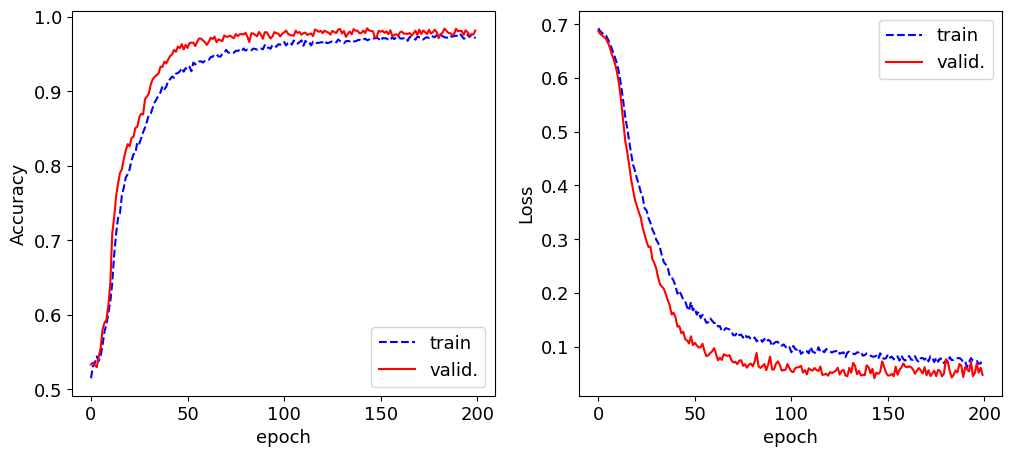

In [38]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


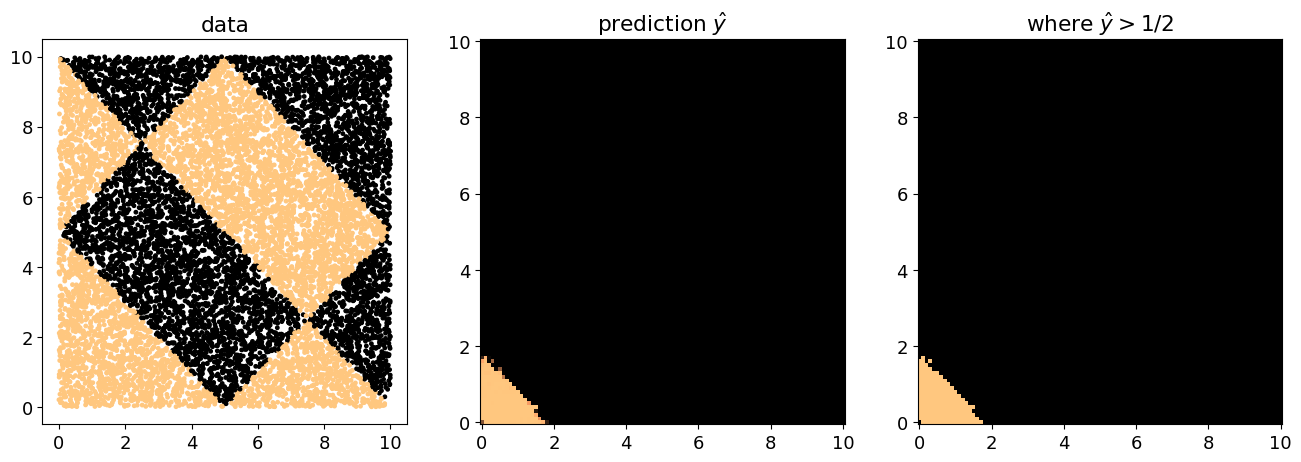

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [39]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")